In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
df.shape

(2240, 22)

# Data preprocessing

# 1. Handle Missing Value

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Featuer Engineering

In [8]:
# Age
df["Age"] = 2026-df["Year_Birth"]

In [9]:
# Customer joining date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customers_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [10]:
# spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"] 

In [11]:
# children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [12]:
# Education

df["Education"] = df["Education"].replace({
    "2n Cycle": "Undergraduate", "Basic": "Undergraduate",
     "PhD": "Postgraduated", "Master": "Postgraduated",
    "Graduation": "Graduate"
})

In [13]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduated     856
Undergraduate     257
Name: count, dtype: int64

In [14]:
# Marital Status

df["Living_with"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone", "Widow": "Alone",
    "Absurd": "Alone", "YOLO": "Alone"
})

In [15]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customers_Tenure_Days',
       'Total_Spending', 'Total_Children', 'Living_with'],
      dtype='object')

# Drop Column

In [16]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [17]:
df_cleaned.shape

(2240, 15)

In [18]:
df.shape

(2240, 27)

In [19]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customers_Tenure_Days,Total_Spending,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduated,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

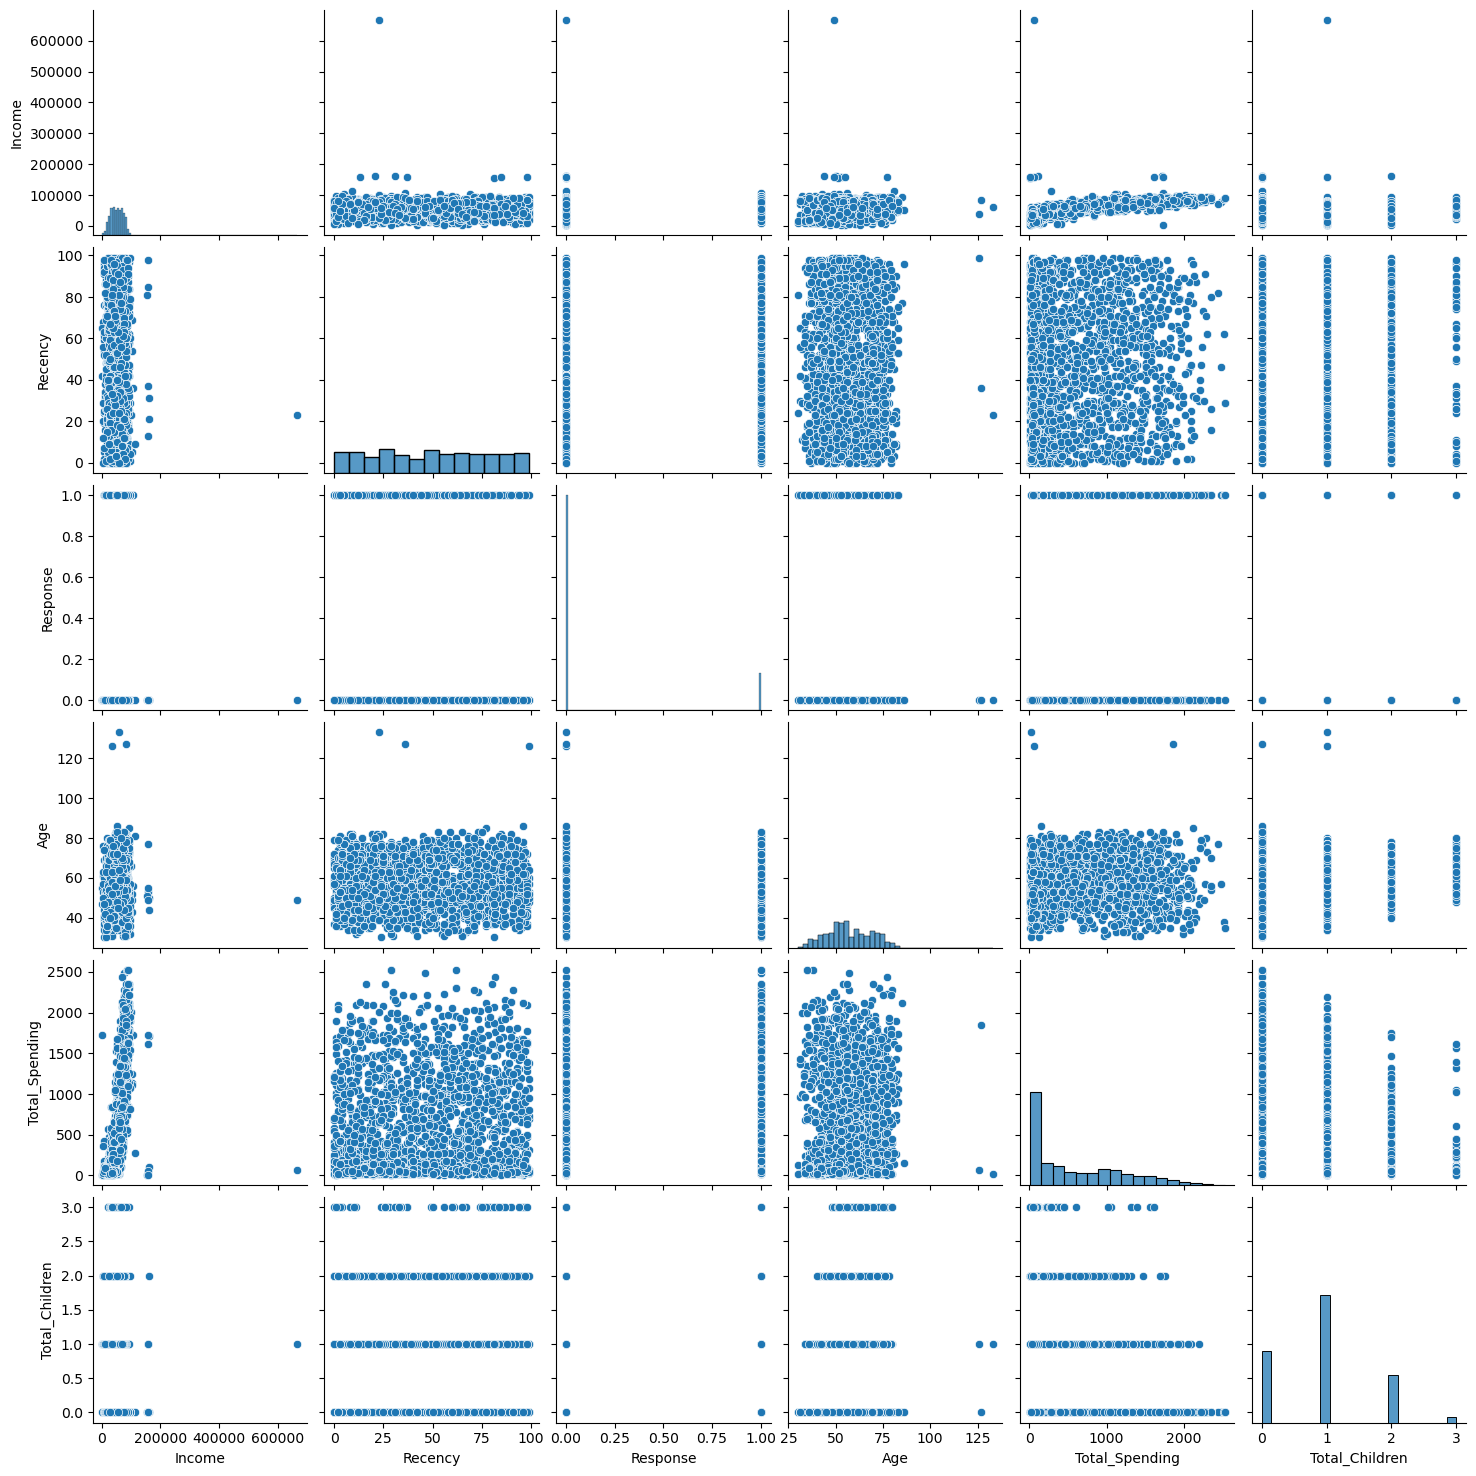

In [20]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative feature of some features - pair plot
sns.pairplot(df_cleaned[cols])

In [21]:
# Remove Outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


# Heatmap

In [22]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

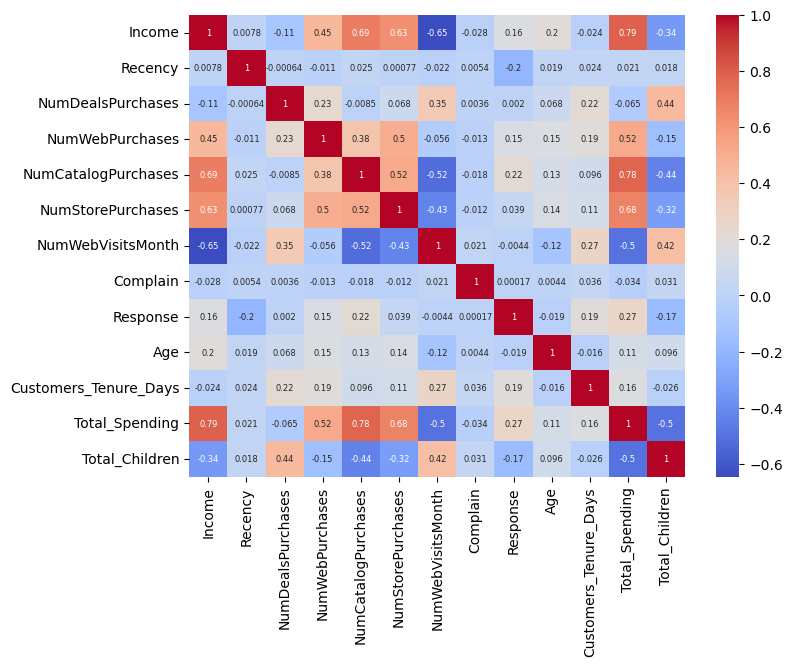

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap = "coolwarm"
)

# Encoding

In [24]:
from sklearn.preprocessing import OneHotEncoder

In [33]:
ohe = OneHotEncoder() # dropfirst feature we don't use in clustering because it might loss important data.

cat_cols = ["Education", "Living_with"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols]) # we got encoded columns we have to convert into dataframe

In [34]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [35]:
enc_df.head()

,Education_Graduate,Education_Postgraduated,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [36]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

In [38]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customers_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduated,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
X = df_encoded

In [41]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualize

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [45]:
pca.explained_variance_ratio_ # around 43% information 3d model is gathering..

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

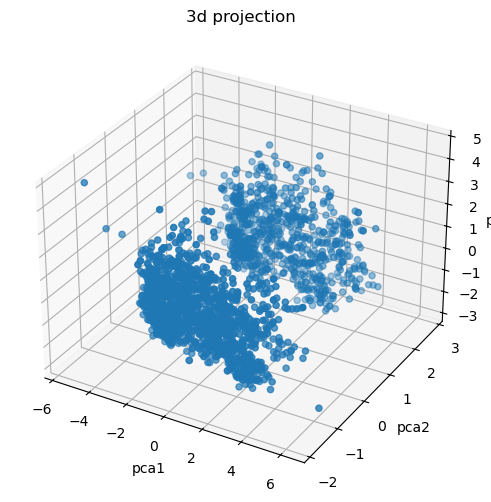

In [53]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3d projection")

# Analyze K Value

# 1. Elbow Method

In [55]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k , random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)


In [56]:
Knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_K = Knee.elbow

In [57]:
print("best K = ", optimal_K)

best K =  4


Text(0, 0.5, 'WCSS')

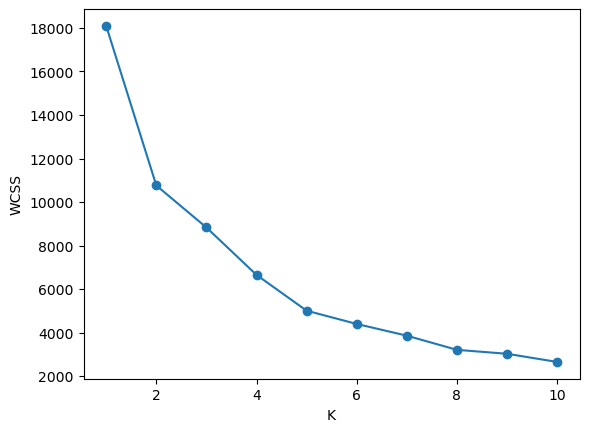

In [58]:
# plot

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

# 2. Silhouette Score

In [59]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score =  silhouette_score(X_pca,labels)

    scores.append(score)

Text(0, 0.5, 'silhouette score')

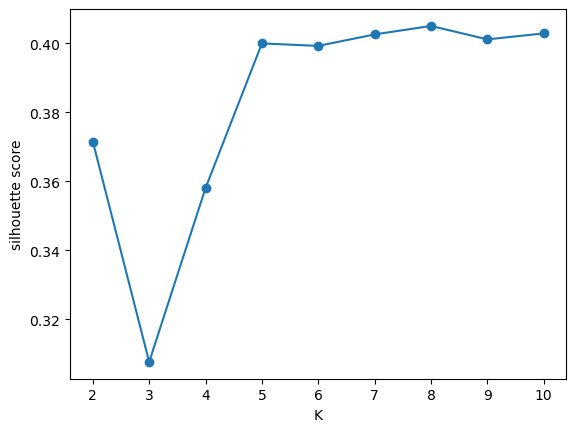

In [61]:
# plot
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("silhouette score")

Text(0, 0.5, 'SS')

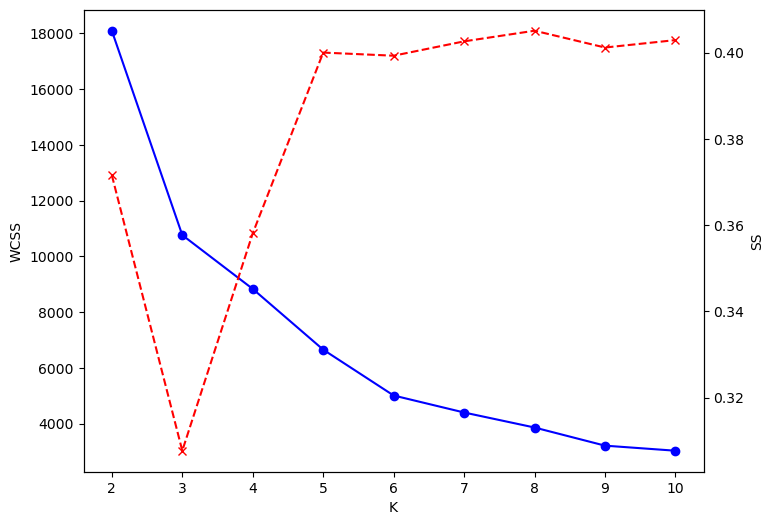

In [67]:
# Combined plot 

K_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(K_range, wcss[:len(K_range)], color="blue", marker="o")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx() # both have same x
ax2.plot(K_range, scores[:len(K_range)], color="red", marker="x", linestyle="--")
ax2.set_ylabel("SS")

# Clustering

In [70]:
# Kmeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_pca)

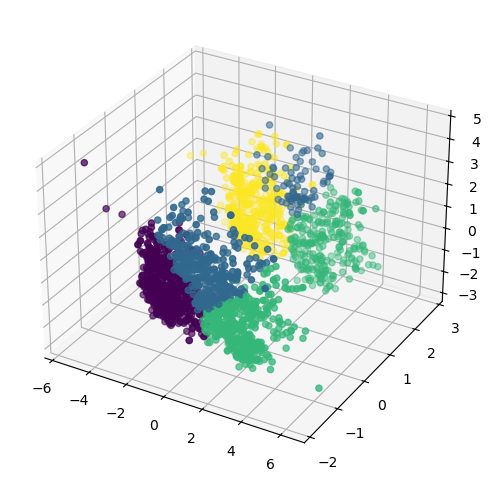

In [71]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels)

In [73]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

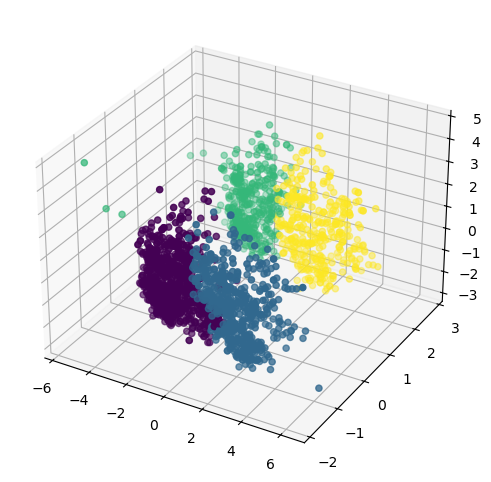

In [74]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_agg)

# Characterization of clusters

In [80]:
X["clusters"] = labels_agg

<Axes: xlabel='clusters', ylabel='count'>

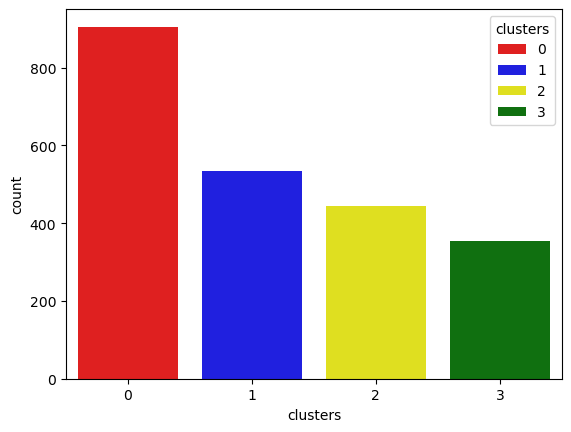

In [81]:
pal = ["red", "Blue", "yellow", "green"]

sns.countplot(x=X["clusters"], palette=pal, hue=X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

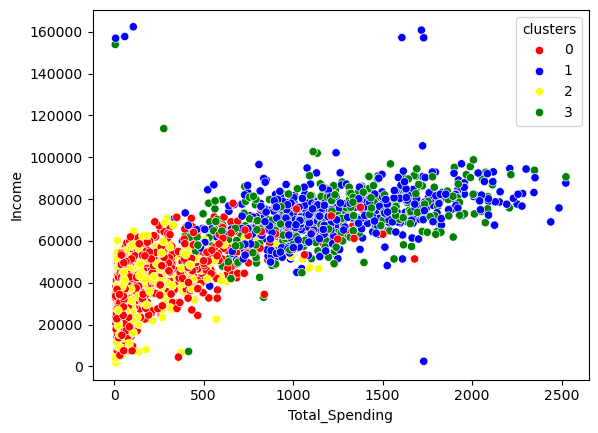

In [82]:
# Income & Total spending pattern
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], palette=pal, hue=X["clusters"])

In [84]:
# cluster summary

cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customers_Tenure_Days  Total_Spending  \
cl